#**Tugas 11: Statistical Modeling & Prediction: Linear Regression - Pengantar Data Sains**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 11**

Gunakan **1 dataset publik** atau dataset sintetis yang Anda rancang sendiri, relevan dengan topik pendidikan, kesehatan, ekonomi, bisnis, lingkungan, atau sosial. Lakukan analisis regresi linear secara lengkap dengan tahapan berikut.

## Soal

### 1. Jelaskan dataset yang digunakan

Jelaskan:

- nama dataset;
- sumber dataset atau alasan pembuatan dataset sintetis;
- unit analisis;
- variabel respons;
- variabel prediktor;
- jenis variabel: numerik atau kategorik.

### 2. Muat dataset ke Python menggunakan `pandas`

Tampilkan:

- `shape`;
- `head()`;
- `info()`;
- `describe()`;
- jumlah missing values;
- jumlah data duplikat.

### 3. Lakukan eksplorasi data

Minimal tampilkan:

- distribusi variabel respons;
- scatterplot respons terhadap minimal dua prediktor numerik;
- korelasi antarvariabel numerik;
- ringkasan respons berdasarkan satu variabel kategorik jika tersedia.

### 4. Bangun model regresi linear sederhana

Pilih satu prediktor utama dan buat model:

$$
Y_i=\beta_0+\beta_1X_i+\varepsilon_i.
$$

Tampilkan:

- ringkasan model;
- persamaan regresi estimasi;
- interpretasi intercept dan slope;
- nilai $R^2$;
- residual plot.

### 5. Bangun model regresi linear berganda

Gunakan minimal dua prediktor. Tampilkan:

- ringkasan model;
- interpretasi minimal tiga koefisien;
- $R^2$ dan adjusted $R^2$;
- confidence interval koefisien;
- VIF untuk memeriksa multikolinearitas.

### 6. Periksa asumsi regresi linear

Periksa:

- linearitas;
- homoskedastisitas;
- normalitas residual;
- independensi residual jika relevan;
- outlier, leverage, dan influence.

Gunakan visualisasi dan/atau uji statistik yang sesuai.

### 7. Lakukan prediksi dan evaluasi model

Bagi data menjadi train dan test set. Hitung minimal:

- MAE;
- RMSE;
- $R^2$ test.

Buat plot aktual vs prediksi dan tuliskan interpretasi.

### 8. Tulis kesimpulan akhir

Kesimpulan harus memuat:

- prediktor yang paling penting secara statistik atau substantif;
- apakah model cukup baik untuk interpretasi;
- apakah model cukup baik untuk prediksi;
- keterbatasan analisis;
- rekomendasi perbaikan model.


## 1) Deskripsi Dataset

Dataset yang digunakan adalah **[Global Stock Market Trading Value](https://www.kaggle.com/datasets/omarshahrukh/stocks-traded-total-value-current-us)** yang bersumber dari World Bank (World Development Indicators).

Dataset ini mencakup periode waktu yang panjang, yaitu dari tahun 1975 hingga 2024 sehingga dapat dikategorikan sebagai data time series (deret waktu) dengan dimensi lintas negara.

Unit analisis pada dataset ini adalah **country-year**, di mana setiap baris merepresentasikan satu negara pada satu tahun tertentu dengan nilai aktivitas pasar saham yang tercatat.
Dataset ini menggambarkan total nilai transaksi pasar saham sebagai indikator aktivitas dan likuiditas pasar keuangan global.

Variabel utama dalam dataset meliputi:

* `country`: nama negara atau wilayah
* `year`: tahun observasi (1975–2024)
* `stock_trading_value`: total nilai transaksi pasar saham dalam USD

## 2) Memuat Dataset

Pada tahap awal, dataset dimuat ke Python agar dapat dianalisis lebih lanjut. Pemeriksaan awal seperti ukuran data, tipe variabel, dan beberapa baris pertama penting dilakukan untuk memahami struktur dataset sebelum melakukan analisis statistik.

In [3]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# Membaca data
df = pd.read_csv("stocks_traded_total_value.csv")

# Menampilkan ukuran dataset
print("Shape dataset:")
print(df.shape)

# Menampilkan 5 data pertama
print("\nHead dataset:")
display(df.head())

# Informasi dataset
print("\nInfo dataset:")
df.info()

# Mengecek missing value
print("\nMissing values:")
print(df.isnull().sum())

Shape dataset:
(4080, 4)

Head dataset:


,Country Name,Year,Value (USD),Status
0,Arab World,2006,1.585737e+12,Normal value
1,Arab World,2010,3.069249e+11,Normal value
2,Arab World,2011,3.792060e+11,Normal value
3,Arab World,2012,5.984638e+11,Normal value
4,Arab World,2014,8.071476e+11,Normal value



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  4080 non-null   object 
 1   Year          4080 non-null   int64  
 2   Value (USD)   4080 non-null   float64
 3   Status        4080 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 127.6+ KB

Missing values:
Country Name    0
Year            0
Value (USD)     0
Status          0
dtype: int64


**Interpretasi:**

### a) Shape dataset

Dataset memiliki ukuran **(4080, 4)** yang berarti terdapat 4080 observasi (baris data) dan 4 variabel (kolom).

### b) Head dataset

Lima baris pertama menunjukkan bahwa dataset berisi informasi mengenai:

* nama negara atau wilayah,
* tahun observasi,
* total nilai transaksi pasar saham dalam USD,
* status data.

Nilai `Value (USD)` memiliki skala yang sangat besar (mencapai triliunan USD) sehingga dapat diasumsikan bahwa distribusi data kemungkinan tidak simetris dan berpotensi memiliki skewness tinggi.

### c) Info dataset

Berdasarkan hasil `info()`, dataset memiliki:

* Dua variabel numerik, yaitu `Year` bertipe `int64` dan `Value (USD)` bertipe `float64`

* Dua variabel kategorik, yaitu `Country Name` dan `Status`.

Seluruh variabel memiliki **4080 non-null values** sehingga dataset tidak memiliki missing values dan dapat langsung digunakan untuk analisis statistik tanpa proses imputasi data.

### d) Missing values

Hasil pemeriksaan missing values menunjukkan seluruh variabel memiliki nilai **0 missing values**. Hal ini berarti dataset lengkap dan tidak memerlukan proses penanganan data hilang (*missing value handling*) sebelum dilakukan eksplorasi data maupun uji hipotesis.

## 3) Eksplorasi Data

Eksplorasi awal dilakukan untuk memahami distribusi data, mendeteksi outlier, dan melihat pola antar kelompok. Visualisasi seperti histogram dan boxplot membantu interpretasi data sebelum melakukan uji hipotesis.

Descriptive Statistics:


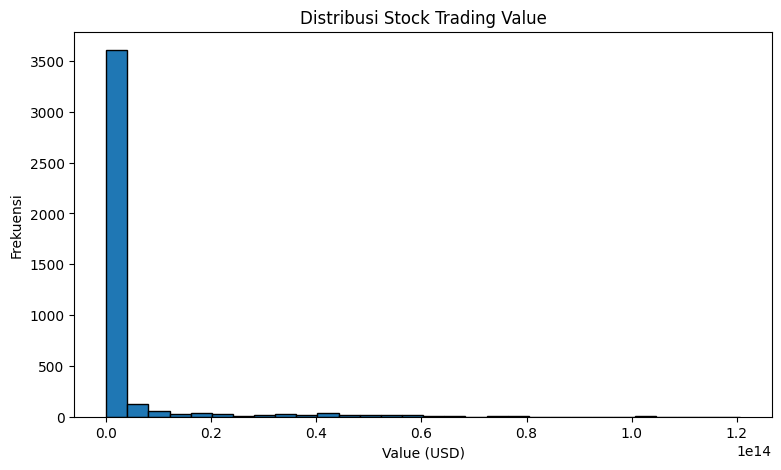

In [5]:
# Statistik deskriptif
print("Descriptive Statistics:")
df.describe(include='all')

# Histogram distribusi nilai trading
plt.figure(figsize=(9,5))
plt.hist(df['Value (USD)'], bins=30, edgecolor='black')
plt.title('Distribusi Stock Trading Value')
plt.xlabel('Value (USD)')
plt.ylabel('Frekuensi')
plt.show()

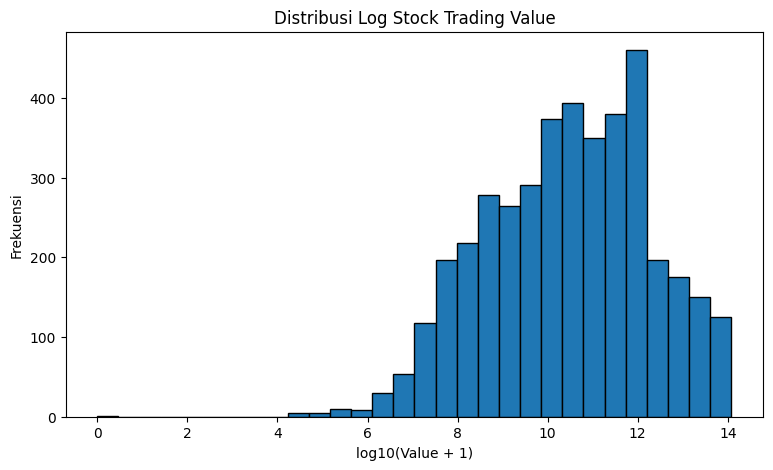

In [7]:
# Karena data sangat besar dan right-skewed, gunakan log transform
df['log_value'] = np.log10(df['Value (USD)'] + 1)

# Histogram log transform
plt.figure(figsize=(9,5))
plt.hist(df['log_value'], bins=30, edgecolor='black')
plt.title('Distribusi Log Stock Trading Value')
plt.xlabel('log10(Value + 1)')
plt.ylabel('Frekuensi')
plt.show()

<Figure size 800x500 with 0 Axes>

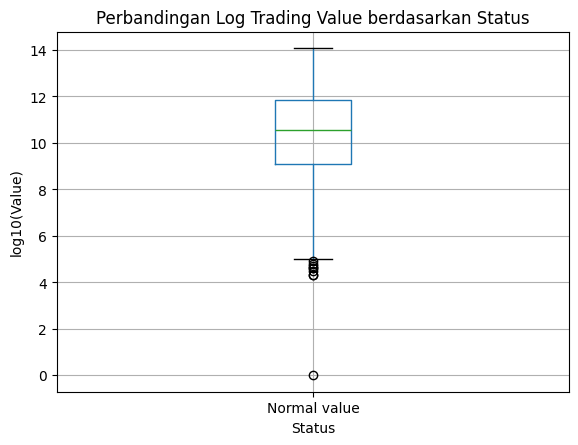

In [8]:
# Boxplot berdasarkan status
plt.figure(figsize=(8,5))
df.boxplot(column='log_value', by='Status')
plt.title('Perbandingan Log Trading Value berdasarkan Status')
plt.suptitle('')
plt.xlabel('Status')
plt.ylabel('log10(Value)')
plt.show()

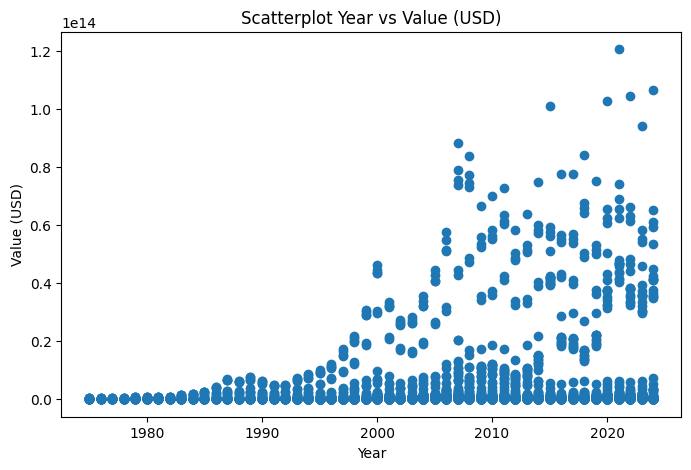

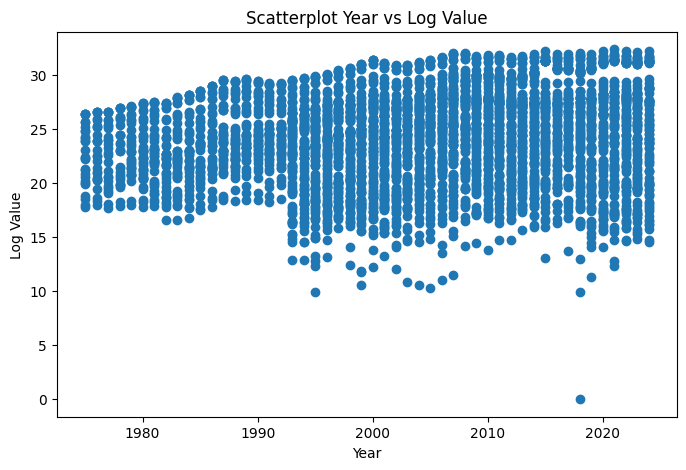

In [14]:
# Scatterplot Respons terhadap Prediktor Numerik
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Value (USD)'])
plt.xlabel('Year')
plt.ylabel('Value (USD)')
plt.title('Scatterplot Year vs Value (USD)')
plt.show()
# Membuat variabel numerik tambahan
df['Log_Value'] = np.log1p(df['Value (USD)'])
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Log_Value'])
plt.xlabel('Year')
plt.ylabel('Log Value')
plt.title('Scatterplot Year vs Log Value')
plt.show()

                 Year  Value (USD)  Log_Value
Year         1.000000     0.212299   0.132231
Value (USD)  0.212299     1.000000   0.492725
Log_Value    0.132231     0.492725   1.000000


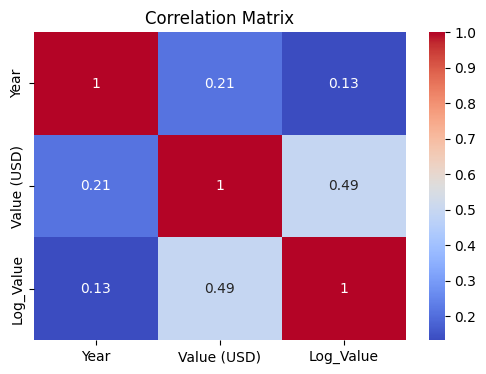

In [11]:
# Korelasi Numerik
import seaborn as sns
numeric_df = df[['Year', 'Value (USD)', 'Log_Value']]
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Interpretasi:**

### a) Statistik deskriptif `Value (USD)`

Hasil statistik deskriptif memperlihatkan bahwa distribusi nilai transaksi pasar saham memiliki rentang yang sangat lebar. Mayoritas negara memiliki nilai transaksi relatif kecil dibanding beberapa negara dengan aktivitas pasar saham sangat besar.

Beberapa poin penting:
- Nilai minimum adalah 0 USD
- Nilai maksimum mencapai sekitar 1.2 × 10¹⁴ USD
- Rata-rata sebesar 3.39 × 10¹² USD
- Median hanya sekitar 3.58 × 10¹⁰ USD

Perbedaan yang sangat besar antara mean dan median menunjukkan bahwa distribusi data bersifat right **skewed (miring ke kanan)**. Artinya, terdapat sejumlah kecil observasi dengan nilai transaksi sangat besar yang menarik rata-rata menjadi jauh lebih tinggi.

Kondisi tersebut menunjukkan adanya **outlier alami** dalam data ekonomi global, terutama dari negara dengan kapitalisasi pasar dan aktivitas trading yang sangat besar.


### b) Histogram distribusi `Value (USD)`

Histogram awal menunjukkan distribusi data sangat tidak simetris dan cenderung **right skewed**.

Akibatnya:

* distribusi memanjang ke sisi kanan,
* visualisasi menjadi kurang optimal,
* pola distribusi sulit diamati secara jelas.

### c) Histogram setelah log transform

Transformasi log dilakukan menggunakan:
#### **log₁₀(Value + 1)**

Setelah transformasi log:

* distribusi menjadi lebih mendekati simetris,
* skewness berkurang,
* nilai ekstrem menjadi lebih terkompresi,
* pola distribusi data lebih mudah diamati.

Transformasi ini penting karena banyak metode statistik parametrik bekerja lebih baik pada data yang distribusinya lebih stabil dan tidak terlalu skewed.
Selain itu, log transform membantu mengurangi pengaruh outlier ekstrem pada analisis.

### d) Boxplot berdasarkan `Status`

Boxplot digunakan untuk membandingkan distribusi `log_value` berdasarkan kategori `Status`.

Namun, hasil eksplorasi menunjukkan bahwa seluruh observasi hanya memiliki satu kategori yaitu `"Normal value"`.

Akibatnya tidak terdapat variasi kelompok dan boxplot tidak memberikan perbandingan antar kategori. Karena hanya terdapat satu kelas, variabel ini kemungkinan tidak relevan digunakan dalam uji hipotesis berbasis perbandingan kelompok.

### e) Scatterplot Respons terhadap Prediktor Numerik

Scatterplot digunakan untuk melihat hubungan antara variabel respons dengan prediktor numerik serta mengecek indikasi hubungan linear.

Berdasarkan scatterplot antara `Year` dan `Value (USD)`, terlihat bahwa nilai transaksi pasar saham cenderung meningkat pada tahun-tahun yang lebih baru. Namun, persebaran data sangat lebar dan tidak merata, terutama setelah tahun 2000. Terdapat banyak observasi dengan nilai sangat tinggi yang membentuk pola pencilan (outlier), sehingga hubungan linear sulit terlihat secara jelas pada data asli.

Selain itu, varians data tampak semakin besar seiring bertambahnya tahun. Kondisi ini mengindikasikan adanya kemungkinan heteroskedastisitas, yaitu varians residual yang tidak konstan.

Pada scatterplot `Year` terhadap `Log_Value`, pola hubungan menjadi lebih jelas setelah dilakukan transformasi log. Persebaran data terlihat lebih stabil dan outlier ekstrem menjadi lebih terkompresi. Meskipun hubungan linear masih tidak terlalu kuat, transformasi log membantu memperlihatkan kecenderungan peningkatan nilai transaksi dari waktu ke waktu dengan distribusi yang lebih teratur.

Secara umum, transformasi log membuat data lebih sesuai untuk analisis regresi linear dibandingkan menggunakan nilai asli `Value (USD)`.

### f) Korelasi Antarvariabel Numerik

Analisis korelasi dilakukan untuk melihat kekuatan hubungan linear antarvariabel numerik.

Berdasarkan matriks korelasi, variabel `Year` memiliki korelasi positif sebesar 0.212 terhadap `Value (USD)`. Nilai ini menunjukkan hubungan linear positif yang relatif lemah, sehingga peningkatan tahun hanya memiliki hubungan kecil terhadap peningkatan nilai transaksi pasar saham.

Sementara itu, korelasi antara `Value (USD)` dan `Log_Value` sebesar 0.493 menunjukkan hubungan positif dengan kekuatan sedang. Hal ini wajar karena `Log_Value` merupakan hasil transformasi langsung dari `Value (USD)`.

Korelasi antara `Year` dan `Log_Value` sebesar 0.132 juga tergolong lemah. Artinya, meskipun terdapat kecenderungan peningkatan nilai transaksi pada tahun yang lebih baru, hubungan linear tersebut tidak terlalu kuat secara keseluruhan.

Secara umum, hasil korelasi menunjukkan bahwa variabel tahun saja kemungkinan belum cukup untuk menjelaskan variasi nilai transaksi pasar saham secara optimal, sehingga diperlukan variabel tambahan atau pendekatan model yang lebih kompleks untuk meningkatkan kemampuan prediksi model.



# 4) Model Regresi Linear Sederhana

## Tujuan

Tahap ini bertujuan untuk membangun model regresi linear sederhana menggunakan satu prediktor utama guna melihat hubungan linear terhadap variabel respons.

Model: 𝑌𝑖 = 𝛽0 + 𝛽1𝑋𝑖 + 𝜀𝑖

                            OLS Regression Results                            
Dep. Variable:            Value (USD)   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     192.5
Date:                Mon, 18 May 2026   Prob (F-statistic):           8.49e-43
Time:                        01:22:12   Log-Likelihood:            -1.2837e+05
No. Observations:                4080   AIC:                         2.567e+05
Df Residuals:                    4078   BIC:                         2.568e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.846e+14    2.8e+13    -13.752      0.0

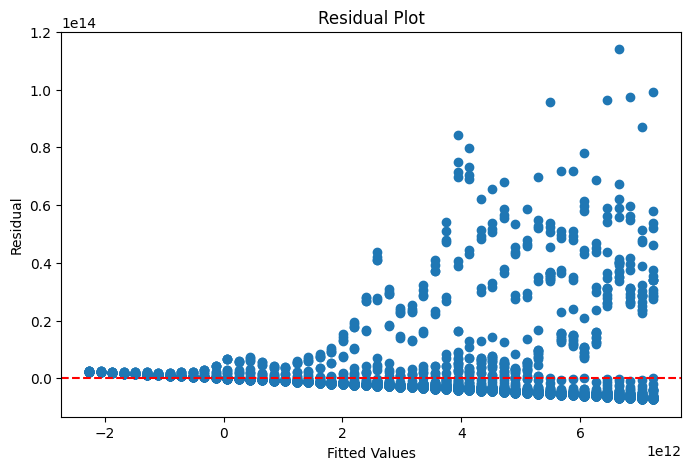

In [15]:
import statsmodels.api as sm

# Variabel prediktor dan respons
X = df[['Year']]
y = df['Value (USD)']

# Menambahkan konstanta
X = sm.add_constant(X)

# Membentuk model regresi linear sederhana
model_simple = sm.OLS(y, X).fit()

# Ringkasan model
print(model_simple.summary())

# Persamaan regresi estimasi
beta0 = model_simple.params['const']
beta1 = model_simple.params['Year']

print(f"Persamaan Regresi:")
print(f"Y = {beta0} + ({beta1} * Year)")

# Nilai R-square
print("R-square:")
print(model_simple.rsquared)

# Residual
residuals = model_simple.resid
fitted = model_simple.fittedvalues

# Residual plot
plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

**Interpretasi:**

Model regresi linear sederhana dibangun menggunakan variabel `Year` sebagai prediktor dan `Value (USD)` sebagai variabel respons. Model digunakan untuk melihat hubungan linear antara tahun pengamatan dengan nilai total transaksi pasar saham.

Model regresi yang diperoleh adalah:
$$
\hat{Y}=-3.846\times10^{14}+(1.936\times10^{11})\times Year
$$

Koefisien slope sebesar (1.936 \times 10^{11}) menunjukkan bahwa setiap kenaikan 1 tahun diperkirakan akan meningkatkan nilai transaksi pasar saham sebesar sekitar 193.6 miliar USD, dengan asumsi faktor lain dianggap konstan.

Sementara itu, nilai intercept bernilai negatif sebesar (-3.846 \times 10^{14}). Nilai ini merupakan estimasi `Value (USD)` ketika `Year = 0`. Namun, karena tahun 0 berada di luar rentang observasi data, intercept dalam konteks ini tidak memiliki makna praktis yang kuat dan lebih berfungsi sebagai konstanta matematis dalam pembentukan model.

Berdasarkan hasil uji parsial, variabel `Year` memiliki nilai p-value sebesar 0.000 (< 0.05), sehingga dapat disimpulkan bahwa `Year` berpengaruh signifikan secara statistik terhadap `Value (USD)`.

Nilai (R^2) sebesar 0.045 menunjukkan bahwa model hanya mampu menjelaskan sekitar 4.5% variasi pada `Value (USD)`, sedangkan sisanya dipengaruhi oleh faktor lain di luar model. Hal ini menunjukkan bahwa kemampuan model sederhana ini dalam menjelaskan variasi data masih relatif rendah.

Selain itu, residual plot menunjukkan pola residual yang semakin menyebar pada fitted values yang lebih besar. Varians residual tampak tidak konstan dan membentuk pola menyerupai kipas (*fan shape*). Kondisi ini mengindikasikan adanya kemungkinan heteroskedastisitas pada model regresi.

Residual juga tampak tidak tersebar secara acak sempurna di sekitar garis nol, serta terdapat beberapa observasi ekstrem dengan residual sangat besar. Hal ini menunjukkan bahwa data kemungkinan mengandung outlier dan distribusi data masih sangat dipengaruhi oleh nilai transaksi yang ekstrem.

Secara umum, model regresi linear sederhana berhasil menunjukkan adanya hubungan positif antara tahun dan nilai transaksi pasar saham, tetapi kemampuan model dalam menjelaskan variasi data masih terbatas dan asumsi regresi linear kemungkinan belum sepenuhnya terpenuhi.



## 5) Model Regresi Linear Berganda

Tahap ini bertujuan untuk membangun model regresi linear berganda dengan lebih dari satu prediktor agar hubungan antarvariabel dapat dianalisis secara simultan.


In [19]:
# Dummy encoding variabel kategorik
df_dummy = pd.get_dummies(df, columns=['Status'], drop_first=True)
df_dummy.columns

# Menentukan variabel prediktor
X_multi = df_dummy[['Year', 'Log_Value']]
y_multi = df_dummy['Value (USD)']

# Menambahkan konstanta
X_multi = sm.add_constant(X_multi)

# Membentuk model regresi linear berganda
model_multiple = sm.OLS(y_multi, X_multi).fit()

# Ringkasan model
print(model_multiple.summary())

# R-square dan Adjusted R-square
print("R-square:")
print(model_multiple.rsquared)

print("Adjusted R-square:")
print(model_multiple.rsquared_adj)
# Confidence interval koefisien
print("Confidence Interval:")
print(model_multiple.conf_int())

# VIF (Variance Inflation Factor)
# VIF digunakan untuk mendeteksi adanya multikolinearitas antarvariabel prediktor.
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_multi.values, i)
    for i in range(X_multi.shape[1])
]

vif_data

                            OLS Regression Results                            
Dep. Variable:            Value (USD)   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     734.3
Date:                Mon, 18 May 2026   Prob (F-statistic):          4.46e-273
Time:                        01:27:48   Log-Likelihood:            -1.2784e+05
No. Observations:                4080   AIC:                         2.557e+05
Df Residuals:                    4077   BIC:                         2.557e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.013e+14   2.47e+13    -12.221      0.0

,Feature,VIF
0,const,25818.447220
1,Year,1.017796
2,Log_Value,1.017796


 **Interpretasi:**

Model regresi linear berganda dibangun menggunakan variabel `Year` dan `Log_Value` sebagai prediktor terhadap `Value (USD)`.

Hasil regresi menunjukkan bahwa kedua prediktor memiliki pengaruh signifikan secara statistik terhadap `Value (USD)` karena masing-masing memiliki p-value sebesar 0.000 (< 0.05).

Koefisien `Year` sebesar (1.366 \times 10^{11}) menunjukkan bahwa setiap kenaikan 1 tahun diperkirakan meningkatkan nilai transaksi pasar saham sebesar sekitar 136.6 miliar USD, dengan asumsi variabel lain konstan.

Sementara itu, koefisien `Log_Value` sebesar (1.291 \times 10^{12}) menunjukkan adanya hubungan positif antara hasil transformasi log dan nilai transaksi pasar saham.

Nilai (R^2) sebesar 0.265 menunjukkan bahwa model mampu menjelaskan sekitar 26.5% variasi pada `Value (USD)`. Nilai adjusted (R^2) yang hampir sama, yaitu 0.264, menunjukkan bahwa penambahan prediktor pada model masih relevan dan tidak menyebabkan overfitting yang besar.

Confidence interval seluruh koefisien tidak melewati nol, sehingga memperkuat indikasi bahwa masing-masing prediktor memiliki pengaruh signifikan terhadap variabel respons.

Berdasarkan hasil VIF, variabel `Year` dan `Log_Value` memiliki nilai sekitar 1.018, yang menunjukkan tidak terdapat indikasi multikolinearitas yang serius antarvariabel prediktor.


## 6) Pemeriksaan Asumsi Regresi Linear

Tahap ini bertujuan untuk memastikan bahwa model regresi memenuhi asumsi-asumsi dasar regresi linear sehingga hasil estimasi model dapat dipercaya.


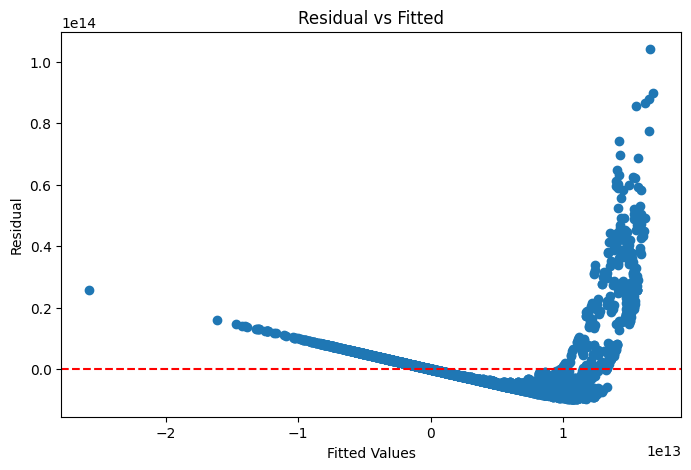

{'LM Statistic': np.float64(397.54532819998997), 'LM-Test p-value': np.float64(4.722030937812672e-87), 'F-Statistic': np.float64(220.06955244870736), 'F-Test p-value': np.float64(1.7392709559701265e-91)}


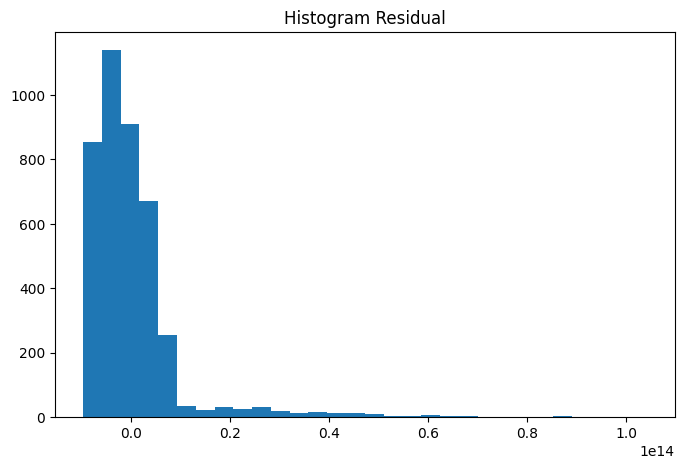

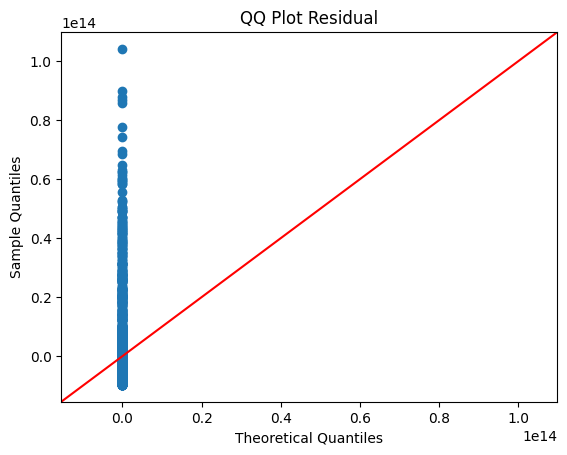

Shapiro-Wilk Test:
ShapiroResult(statistic=np.float64(0.6582570015819237), pvalue=np.float64(1.2934176335578925e-67))
Durbin-Watson:
0.16855937803297213


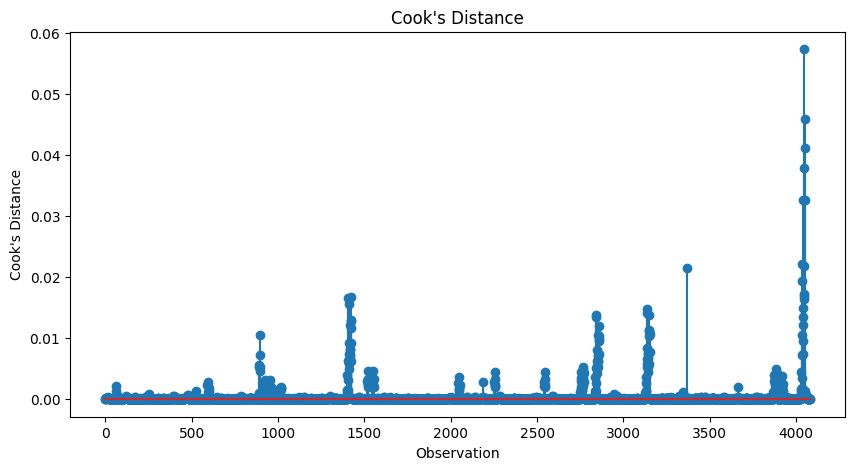

In [20]:

plt.figure(figsize=(8,5))
plt.scatter(model_multiple.fittedvalues, model_multiple.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')
plt.title('Residual vs Fitted')
plt.show()

# Homoskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(
    model_multiple.resid,
    model_multiple.model.exog
)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

# Normalitas Residual
# Histogram residual
plt.figure(figsize=(8,5))
plt.hist(model_multiple.resid, bins=30)
plt.title('Histogram Residual')
plt.show()

# QQ Plot
sm.qqplot(model_multiple.resid, line='45')
plt.title('QQ Plot Residual')
plt.show()

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(model_multiple.resid)
print("Shapiro-Wilk Test:")
print(shapiro_test)

# Independensi Residual
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(model_multiple.resid)

print("Durbin-Watson:")
print(dw)

# Outlier, Leverage, dan Influence
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(model_multiple)
cooks = influence.cooks_distance[0]

plt.figure(figsize=(10,5))
plt.stem(np.arange(len(cooks)), cooks)
plt.title("Cook's Distance")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.show()

**Interpretasi:**

### Homoskedastisitas

Pemeriksaan homoskedastisitas dilakukan untuk memastikan varians residual konstan.

Berdasarkan plot *Residual vs Fitted*, residual tidak tersebar secara acak di sekitar garis nol. Pola residual terlihat membentuk pola melengkung dan penyebaran residual semakin besar pada fitted values yang tinggi. Kondisi ini menunjukkan adanya indikasi heteroskedastisitas, yaitu varians residual yang tidak konstan.

Hasil uji Breusch-Pagan juga menunjukkan nilai p-value yang sangat kecil ((< 0.05)), sehingga hipotesis nol homoskedastisitas ditolak. Dengan demikian, dapat disimpulkan bahwa model mengalami heteroskedastisitas.

### Normalitas Residual

Pemeriksaan normalitas residual dilakukan untuk melihat apakah residual berdistribusi normal.

Histogram residual menunjukkan distribusi residual cenderung tidak simetris dan sangat skewed ke kanan. Selain itu, QQ Plot memperlihatkan banyak titik residual yang jauh menyimpang dari garis diagonal, terutama pada bagian ekor distribusi.

Hasil uji Shapiro-Wilk menghasilkan p-value yang sangat kecil ((< 0.05)), sehingga hipotesis nol normalitas residual ditolak. Hal ini menunjukkan bahwa residual model tidak berdistribusi normal.

Kondisi tersebut kemungkinan dipengaruhi oleh adanya outlier dan distribusi data ekonomi yang sangat ekstrem.

### Independensi Residual

Pemeriksaan independensi residual dilakukan untuk melihat apakah residual saling bebas.

Nilai Durbin-Watson sebesar sekitar 0.169 menunjukkan adanya indikasi autokorelasi positif pada residual. Nilai ini cukup jauh dari angka 2 yang umumnya menunjukkan residual independen.

Dengan demikian, residual pada model kemungkinan belum sepenuhnya saling bebas.

### Outlier, Leverage, dan Influence

Tahap ini dilakukan untuk mendeteksi observasi yang memiliki pengaruh besar terhadap model regresi.

Berdasarkan plot Cook’s Distance, terdapat beberapa observasi dengan nilai Cook’s Distance yang relatif tinggi dibanding observasi lainnya. Hal ini menunjukkan adanya beberapa data yang memiliki pengaruh besar terhadap pembentukan model regresi.

Sebagian besar observasi memiliki nilai Cook’s Distance mendekati nol, namun beberapa titik ekstrem terlihat menonjol, terutama pada observasi bagian akhir. Kondisi ini mengindikasikan adanya outlier atau observasi berpengaruh tinggi (*influential observations*) dalam dataset.

Keberadaan observasi ekstrem tersebut dapat memengaruhi estimasi parameter model dan menjadi salah satu penyebab pelanggaran asumsi normalitas maupun homoskedastisitas pada model regresi.


## 7) Prediksi dan Evaluasi Model

Tahap ini bertujuan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data baru menggunakan data train dan test.


MAE: 5469649324015.802
RMSE: 8769982254388.1875
R-square Test: 0.2709619774454799


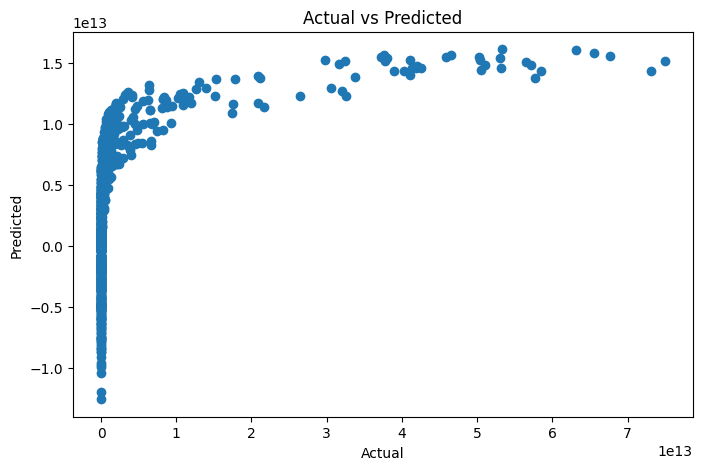

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membagi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

# Membentuk model
model_eval = sm.OLS(y_train, X_train).fit()

# Prediksi data test
y_pred = model_eval.predict(X_test)

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R-square Test:", r2)

# Plot aktual vs prediksi
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

**Interpretasi:**

Evaluasi model dilakukan menggunakan data train dan test untuk melihat kemampuan model dalam melakukan prediksi terhadap data baru.

Hasil evaluasi menunjukkan bahwa nilai MAE sebesar sekitar (5.47 \times 10^{11}) USD. Nilai ini menunjukkan rata-rata kesalahan absolut prediksi model terhadap nilai aktual masih cukup besar.

Sementara itu, nilai RMSE sebesar sekitar (8.77 \times 10^{11}) USD menunjukkan bahwa model masih menghasilkan error prediksi yang relatif tinggi, terutama karena adanya beberapa observasi ekstrem dengan nilai transaksi sangat besar.

Nilai (R^2) test sebesar 0.271 menunjukkan bahwa model mampu menjelaskan sekitar 27.1% variasi data pada data pengujian. Hal ini menunjukkan bahwa kemampuan prediksi model masih tergolong rendah hingga sedang.

Berdasarkan plot aktual vs prediksi, terlihat bahwa model mampu mengikuti pola umum kenaikan data, terutama pada nilai transaksi menengah hingga tinggi. Namun, masih terdapat penyebaran prediksi yang cukup besar dan beberapa prediksi bernilai negatif pada observasi tertentu.

Secara umum, model memiliki kemampuan prediksi dasar yang cukup untuk menangkap tren umum data, tetapi performanya masih terbatas karena data memiliki distribusi sangat skewed, heteroskedastisitas, serta banyak outlier ekstrem.


## 8) Kesimpulan Akhir

Berdasarkan hasil analisis regresi linear pada dataset *Stocks Traded Total Value*, diketahui bahwa variabel `Year` dan `Log_Value` memiliki pengaruh signifikan terhadap `Value (USD)` baik pada model regresi sederhana maupun regresi linear berganda. Hubungan yang diperoleh cenderung positif, yang menunjukkan bahwa nilai transaksi pasar saham cenderung meningkat pada tahun-tahun yang lebih baru.

Model regresi linear berganda memberikan performa yang lebih baik dibanding regresi sederhana dengan nilai (R^2) sekitar 26.5%, sehingga mampu menjelaskan variasi data lebih baik. Selain itu, hasil VIF menunjukkan tidak terdapat masalah multikolinearitas yang serius antarvariabel prediktor.

Namun, hasil pemeriksaan asumsi regresi menunjukkan bahwa model masih mengalami beberapa pelanggaran asumsi, seperti heteroskedastisitas, residual yang tidak normal, autokorelasi positif, serta keberadaan outlier dan observasi berpengaruh tinggi. Kondisi ini dipengaruhi oleh distribusi data ekonomi global yang sangat skewed dan memiliki banyak nilai ekstrem.

Pada tahap evaluasi prediksi, model mampu menangkap pola umum data tetapi masih menghasilkan error prediksi yang cukup besar. Nilai (R^2) test sebesar sekitar 27.1% menunjukkan kemampuan prediksi model masih tergolong terbatas.

Secara umum, model regresi linear pada analisis ini cukup baik untuk memberikan gambaran hubungan antarvariabel secara dasar, tetapi belum optimal untuk prediksi yang akurat. Untuk pengembangan lebih lanjut, dapat dilakukan penambahan variabel prediktor lain, penggunaan transformasi data tambahan, penanganan outlier, atau penerapan metode regresi yang lebih robust dan fleksibel agar performa model meningkat.
